In [1]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from plotnine import *

import polars as pl
import numpy as np

df_long = pl.read_csv('../../data/dl-foundational/df_metrics_by_data.csv')

print(df_long['Model'].unique().to_list())

# Filter to key models
key_models = ['XGBoost', 'LightGBM', 'CatBoost', 'RealMLP', 'TabM', 'TabPFNv2', 'TabDPT', 'AutoGluon']

df_plot = df_long.filter(pl.col('Model').is_in(key_models)).with_columns(
    pl.when(pl.col("Model").is_in(['XGBoost', 'LightGBM', 'CatBoost']))
    .then(pl.lit('Boosting'))
    .otherwise(pl.lit('DL'))
    .alias('Model Group')
)


['KNN', 'TabICL', 'EBM', 'FastAIMLP', 'CatBoost', 'XGBoost', 'TabDPT', 'ExtraTrees', 'RF', 'LightGBM', 'TorchMLP', 'AutoGluon', 'Linear', 'RealMLP', 'TabPFNv2', 'MNCA', 'TabM']


In [32]:


df_unpivot = (
    df_plot
    .unpivot(
        index=[col for col in df_plot.columns if col not in ['N', 'perc_cat', 'd']],
        on=['N', 'perc_cat', 'd'],
        variable_name='feature',
        value_name='feature_val'
    )
)

df_binned = (
    df_unpivot
    .with_columns(
        pl.when(pl.col('feature') == 'N')
        .then(pl.col('feature_val').log10().round(1))
        .when(pl.col('feature') == 'd')
        .then(pl.col('feature_val').log10().round(1))
        .otherwise(pl.col('feature_val').round(1))
        .alias('binned_val')
    )
    .group_by(['feature', 'binned_val', 'Model Group', 'Metric', 'Setting', 'Name'])
    .agg(pl.col('improvability').mean().alias('avg_improvability'))
)

facet_order = sorted(df_plot['Setting'].unique())
metric_order = ['AUC', 'logloss', 'rmse']

model_group_colors = {
    'Boosting': '#1f77b4',
    'DL': '#ff7f0e'
}

for metric_val in metric_order:
    if metric_val not in df_unpivot['Metric'].unique():
        continue

    df_metric = df_unpivot.filter(pl.col('Metric') == metric_val)
    df_binned_metric = df_binned.filter(pl.col('Metric') == metric_val)

    facet_settings = [s for s in facet_order if s in df_metric['Setting'].unique()]
    n_settings = len(facet_settings)

    for feature in ['N', 'd', 'perc_cat']:
        fig = make_subplots(
            rows=1,
            cols=n_settings,
            subplot_titles=facet_settings,
            horizontal_spacing=0.1
        )

        for i, setting in enumerate(facet_settings, 1):
            df_feature = (
                df_metric
                .filter(
                    (pl.col('Setting') == setting) &
                    (pl.col('feature') == feature)
                )
            )
            df_binned_feature = (
                df_binned_metric
                .filter(
                    (pl.col('Setting') == setting) &
                    (pl.col('feature') == feature)
                )
            )

            log_x = feature != 'perc_cat'

            model_groups = df_feature['Model Group'].unique()

            for model_group in model_groups:
            
                color = model_group_colors.get(model_group, '#888888')
            
                df_group = (
                    df_feature
                    .filter(pl.col('Model Group') == model_group)
                )
            
                df_binned_group = (
                    df_binned_feature
                    .filter(pl.col('Model Group') == model_group)
                    .sort('binned_val')
                )
            
                fig.add_trace(
                    go.Scatter(
                        x=df_group['feature_val'],
                        y=df_group['improvability'],
                        mode='markers',
                        name=model_group,
                        marker=dict(
                            size=8,
                            opacity=0.15,
                            color=color
                        ),
                        customdata=df_group[['Name', 'Model', 'Setting']].to_numpy().tolist(),
                        hovertemplate=(
                            '<b>%{customdata[0]}</b><br>'
                            'Model: %{customdata[1]}<br>'
                            'Setting: %{customdata[2]}<br>'
                            f'{feature}: ' + '%{x}<br>'
                            'Improvability: %{y:.1f}%<br>'
                            '<extra></extra>'
                        ),
                        showlegend=(i == 1),
                        legendgroup=model_group
                    ),
                    row=1,
                    col=i
                )
            
                customdata_avg = [
                    [
                        name,
                        binned_val,
                        df_feature.filter(pl.col('Name') == name)['feature_val'][0],
                        avg_improvability
                    ]
                    for name, binned_val, avg_improvability in zip(
                        df_binned_group['Name'],
                        df_binned_group['binned_val'],
                        df_binned_group['avg_improvability']
                    )
                ]
                
                fig.add_trace(
                    go.Scatter(
                        x=10 ** df_binned_group['binned_val'] if log_x else df_binned_group['binned_val'],
                        y=df_binned_group['avg_improvability'],
                        mode='markers',
                        name=None,
                        marker=dict(
                            size=14,
                            opacity=0.7,
                            symbol='diamond',
                            color=color
                        ),
                        customdata=customdata_avg,
                        hovertemplate=(
                            '<b>%{customdata[0]}</b><br>'
                            + feature + ': %{customdata[2]}<br>'
                            # + feature + ' (binned): %{customdata[1]}<br>'
                            'Avg Improvability: %{customdata[3]:.1f}%<br>'
                            '<extra></extra>'
                        ),
                        showlegend=False,
                        legendgroup=model_group
                    ),
                    row=1,
                    col=i
                )

                x_vals = df_group['feature_val'].to_numpy()
                y_vals = df_group['improvability'].to_numpy()
                # Remove NaNs and, for log_x, non-positive values
                mask = ~np.isnan(x_vals) & ~np.isnan(y_vals)
                if log_x:
                    mask = mask & (x_vals > 0)
                x_vals = x_vals[mask]
                y_vals = y_vals[mask]

                if len(x_vals) > 1:
                    if log_x:
                        x_log = np.log10(x_vals)
                        coeffs = np.polyfit(x_log, y_vals, 1)
                        x_range = np.linspace(x_vals.min(), x_vals.max(), 100)
                        y_fit = coeffs[0] * np.log10(x_range) + coeffs[1]
                    else:
                        coeffs = np.polyfit(x_vals, y_vals, 1)
                        x_range = np.linspace(x_vals.min(), x_vals.max(), 100)
                        y_fit = coeffs[0] * x_range + coeffs[1]
                    
                    fig.add_trace(
                        go.Scatter(
                            x=x_range,
                            y=y_fit,
                            mode='lines',
                            line=dict(
                                color=color,
                                width=2,
                                dash='dash'
                            ),
                            showlegend=False,
                            legendgroup=model_group,
                            hoverinfo='skip'
                        ),
                        row=1,
                        col=i
                    )

            if feature == 'N':
                tickvals = [1e2, 1e3, 1e4, 1e5, 1e6]
                ticktext = ['100', '1k', '10k', '100k', '1M']
            elif feature == 'd':
                tickvals = [1, 10, 100, 1000]
                ticktext = ['1', '10', '100', '1k']
            else:
                tickvals = None
                ticktext = None
            fig.update_xaxes(
                title_text=feature,
                tickvals=tickvals,
                ticktext=ticktext,
                type='log' if log_x else 'linear',
                row=1,
                col=i
            )

            fig.update_yaxes(title_text='Improvability (%)', row=1, col=i, range=[0, None],)

        fig.update_layout(
            title_text=f'Improvability vs {feature} (Metric={metric_val})',
            height=500,
            template='plotly_white',
            hovermode='closest'
        )

        fig.show()

In [33]:
# correlation_results = []

# for setting in df_plot['Setting'].unique():
#     for model_group in df_plot['Model Group'].unique():

#         df_subset = (
#             df_plot
#             .filter(
#                 (pl.col('Setting') == setting)
#                 & (pl.col('Model Group') == model_group)
#             )
#         )

#         df_corr = (
#             df_subset
#             .select(['N', 'd', 'perc_cat', 'improvability'])
#             .drop_nulls()
#         )

#         if df_corr.shape[0] > 1:
#             df_ranked = (
#                 df_corr
#                 .with_columns([
#                     pl.col(col).rank('average').alias(col)
#                     for col in df_corr.columns
#                 ])
#             )
#             corr_matrix = df_ranked.corr()
#             correlation_results.append(
#                 {
#                     'Setting': setting,
#                     'Model Group': model_group,
#                     'Spearman Correlation Matrix': corr_matrix
#                 }
#             )

# correlation_results

In [34]:
# # Spearman correlation for all data (not grouped)
# df_corr_all = (
#     df_plot
#     .select(['N', 'd', 'perc_cat', 'improvability'])
#     .drop_nulls()
# )

# if df_corr_all.shape[0] > 1:
#     df_ranked_all = (
#         df_corr_all
#         .with_columns([
#             pl.col(col).rank('average').alias(col)
#             for col in df_corr_all.columns
#         ])
#     )
#     corr_matrix_all = df_ranked_all.corr()


# corr_matrix_all


In [35]:
import polars as pl
from typing import Optional, List

def compute_correlation_matrix(
    df_plot: pl.DataFrame,
    group_by: Optional[List[str]] = None,
    method: str = 'spearman',
    decimals: int = 3,
    only_with_improvability: bool = False
) -> pl.DataFrame:
    '''
    Compute correlation matrix for selected columns, optionally grouped.
    If only_with_improvability is True, return a tidy DataFrame of correlations
    between each of ['N', 'd', 'perc_cat'] and 'improvability'.
    If False, return all group correlation matrices (or the single matrix if not grouped).

    Args:
        df_plot: polars DataFrame containing the data.
        group_by: List of columns to group by, or None for all data.
        method: 'spearman' for rank correlation, 'pearson' for standard.
        decimals: Number of decimals to round correlations.
        only_with_improvability: If True, return only correlations with 'improvability'.

    Returns:
        polars DataFrame with group_by columns, 'feature', and 'correlation',
        or all group correlation matrices if only_with_improvability is False.
    '''
    cols = ['N', 'd', 'perc_cat', 'improvability']
    corr_rows = []
    results = []

    if group_by:

        df_groups = (
            df_plot
            .select(group_by)
            .unique()
            .sort(group_by)
        )

        groups = df_groups.to_dicts()

        for group in groups:

            df_group = df_plot

            for col in group_by:
                df_group = df_group.filter(pl.col(col) == group[col])

            df_corr = (
                df_group
                .select(cols)
                .drop_nulls()
            )

            if df_corr.shape[0] > 1:

                if method == 'spearman':
                    df_corr = df_corr.with_columns(
                        [pl.col(col).rank('average').alias(col) for col in cols]
                    )

                corr_matrix = (
                    df_corr
                    .corr()
                    .with_columns(pl.col(pl.Float64).round(decimals))
                )

                if only_with_improvability:
                    for feature in ['N', 'd', 'perc_cat']:
                        if (
                            feature in corr_matrix.columns
                            and 'improvability' in corr_matrix.columns
                        ):
                            idx = corr_matrix.columns.index(feature)
                            val = corr_matrix['improvability'][idx]
                        else:
                            val = None

                        group_dict = {col: group[col] for col in group_by}

                        corr_rows.append(
                            {
                                **group_dict,
                                'feature': feature,
                                'correlation': val,
                            }
                        )
                else:
                    group_dict = {col: group[col] for col in group_by}
                    group_dict['correlation_matrix'] = corr_matrix
                    results.append(group_dict)

    else:

        df_corr = (
            df_plot
            .select(cols)
            .drop_nulls()
        )

        if df_corr.shape[0] > 1:

            if method == 'spearman':
                df_corr = df_corr.with_columns(
                    [pl.col(col).rank('average').alias(col) for col in cols]
                )

            corr_matrix = (
                df_corr
                .corr()
                .with_columns(pl.col(pl.Float64).round(decimals))
            )

            if only_with_improvability:
                for feature in ['N', 'd', 'perc_cat']:
                    if (
                        feature in corr_matrix.columns
                        and 'improvability' in corr_matrix.columns
                    ):
                        idx = corr_matrix.columns.index(feature)
                        val = corr_matrix['improvability'][idx]
                    else:
                        val = None

                    corr_rows.append(
                        {
                            'feature': feature,
                            'correlation': val,
                        }
                    )
            else:
                results.append({'correlation_matrix': corr_matrix})

    if only_with_improvability:
        return pl.DataFrame(corr_rows)

    if group_by:
        return pl.DataFrame(results)
    if results:
        return results[0]['correlation_matrix']
    return pl.DataFrame()
# Example usage:
# By group, Spearman
improvability_corr = compute_correlation_matrix(
    df_plot=df_plot,
    group_by=['Metric', 'Model Group', 'Setting'],
    method='pearson',
    only_with_improvability=True
    )
improvability_corr

# test.select('correlation_matrix')[0,0] # only_with_improvability=False

Metric,Model Group,Setting,feature,correlation
str,str,str,str,f64
"""AUC""","""Boosting""","""Default""","""N""",-0.266
"""AUC""","""Boosting""","""Default""","""d""",-0.171
"""AUC""","""Boosting""","""Default""","""perc_cat""",-0.009
"""AUC""","""Boosting""","""Tuned""","""N""",-0.264
"""AUC""","""Boosting""","""Tuned""","""d""",-0.15
…,…,…,…,…
"""rmse""","""DL""","""Tuned""","""d""",-0.031
"""rmse""","""DL""","""Tuned""","""perc_cat""",-0.227
"""rmse""","""DL""","""Tuned + Ens.""","""N""",0.051


/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning:

Saving 6 x 8 in image.

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning:

Filename: improvability_correlation.png



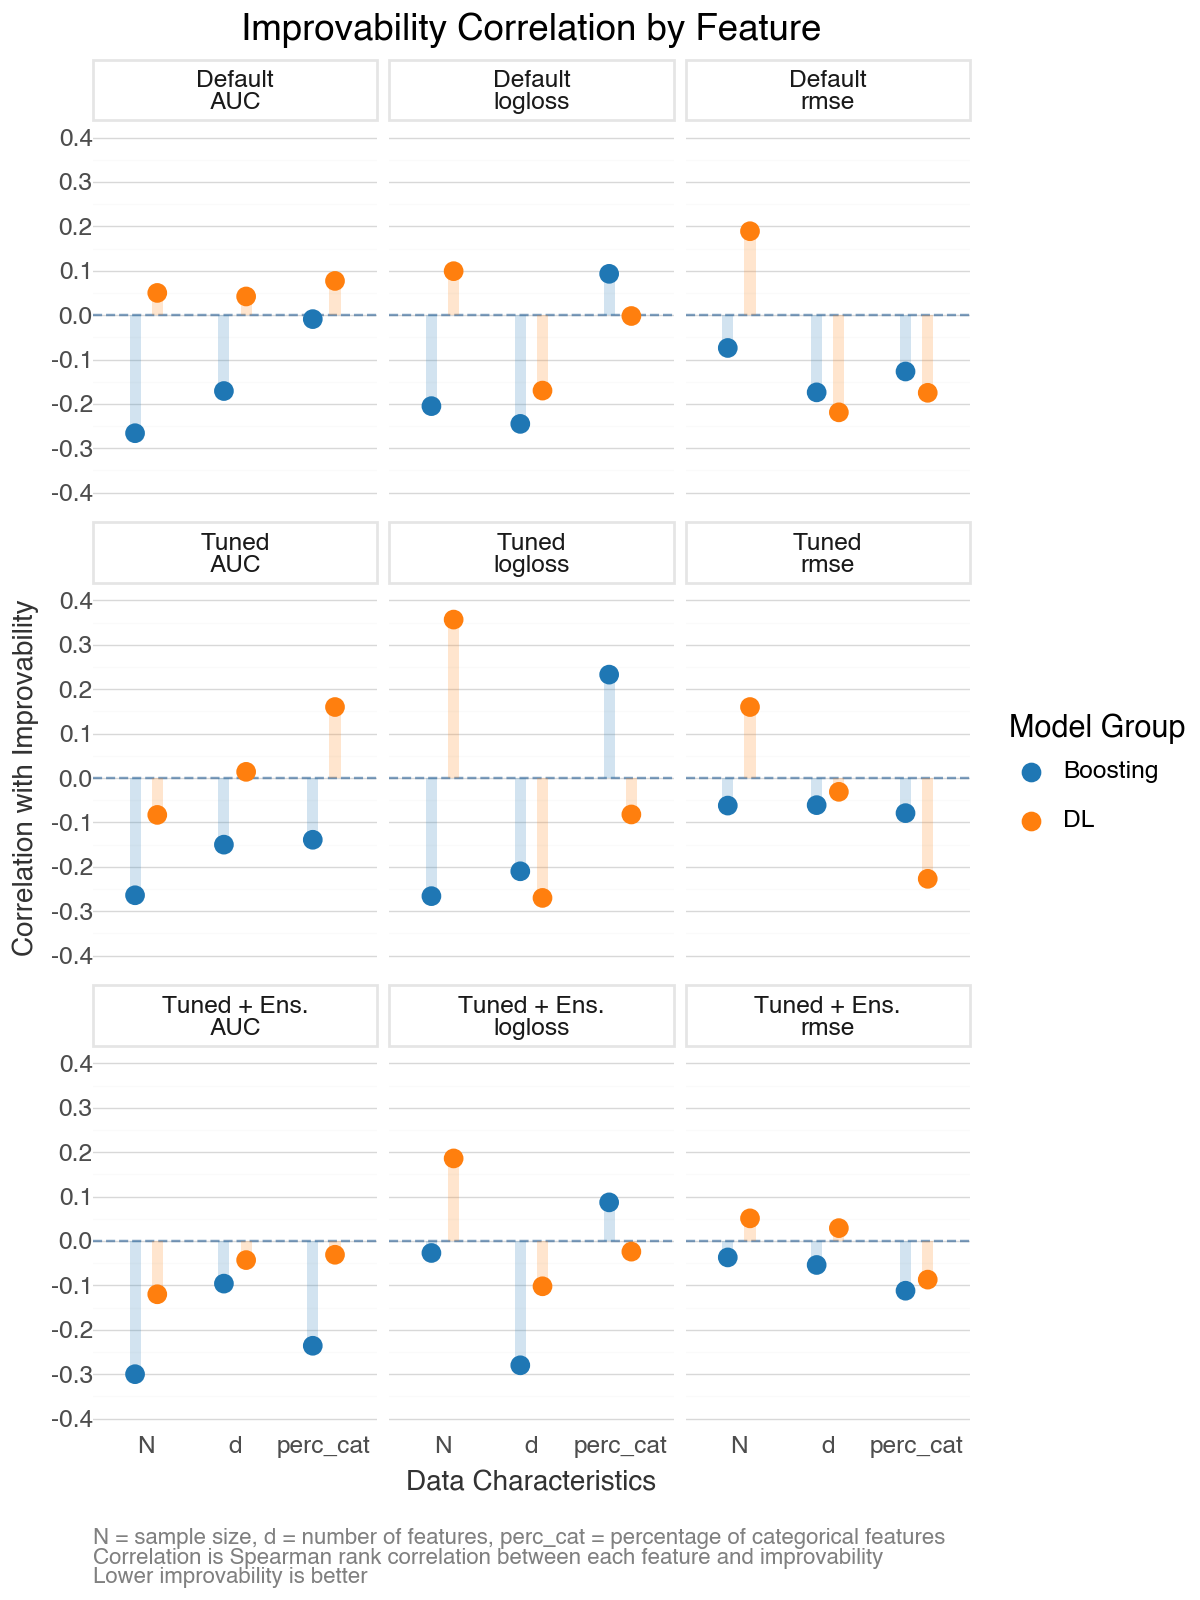

In [ ]:
from plotnine import *

p = (
    ggplot(
        improvability_corr,
        aes(x='feature', y='correlation')
    )
    + geom_hline(yintercept=0, linetype='dashed', color='#084887', alpha=0.5)
    + geom_col(
        aes(fill='Model Group'),
        position=position_dodge(width=0.5),  # match width to points
        width=0.25,
        alpha=0.2,
        color=None,
        show_legend=False
    )
    + geom_point(
        aes(color='Model Group'),
        position=position_dodge(width=0.5),  # match width to columns
        size=3
        )
    + scale_color_manual(values=model_group_colors)
    + scale_fill_manual(values=model_group_colors)
    + facet_wrap('~Setting + Metric', ncol=3)
    + scale_y_continuous(
        limits=(-0.4, 0.4),
        breaks=np.round(np.arange(-0.4, 0.41, 0.1), 2)
    )
    + labs(
        title='Improvability Correlation by Feature',
        caption='\nN = sample size, d = number of features, perc_cat = percentage of categorical features\nCorrelation is Spearman rank correlation between each feature and improvability\nLower improvability is better',
        x='Data Characteristics',
        y='Correlation with Improvability'
    )    
    + theme_bw()
    # + theme_minimal() # if saving
    + theme(
        axis_title=element_text(size=10, color='black', alpha=.8),
        plot_caption=element_text(size=8, color='gray', hjust=0),
        strip_background=element_rect(fill='white', color='black', alpha=.1),
        panel_grid_major_x=element_blank(),
        panel_grid_major_y=element_line(color='gray', alpha=0.3, size=0.5),
        figure_size=(6, 8),
    )

)



p.save('../../img/dl-foundational/improvability_correlation.png', dpi=300)
p.show()

In [7]:
# compute_correlation_matrix(
#     df_plot=df_plot,
#     group_by=['Setting', 'Model Group'],
#     method='spearman'
# )
# # All data, Pearson
# compute_correlation_matrix(
#     df_plot=df_plot,
#     group_by=None,
#     method='pearson'
# )
# # All data, Pearson
# compute_correlation_matrix(
#     df_plot=df_plot,
#     group_by=None,
#     method='spearman'
# )

Other stuff:
pytabkit and autogluon have both been easy to use for my testing, and pytabkit's very sklearn friendly API has been a pleasure to work with for both DL and boosting (it's just as easy either way). I haven't done much with autogluon yet, but in my toy testing it was easy to use and beat both my chosen DL and boosting model with pytabkit with the same amount of effort (but it used an ensemble of 6 models DL + boosting).

Tuned defaults for boosting from application to dozens of datasets is really nice too - very much a fire and forget baseline that will likey be hard to do much better than.